In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from natsort import natsorted
sys.path.append("..")
from dataset.bactero_set import BacteriaDataset, TAXO_LEVELS


## pour construire l'index des labels en local sur une portion de la base refseq

In [47]:
datadir = "/home/hcourtei/Projects/MicroTaxo/codes/data/refseq_with_taxo_merged"
dataset = BacteriaDataset(datadir,logger=None)
dataset.df_bacteria

15:20 - bactero_set.py - INFO - RELOAD bacteria csv Index to /home/hcourtei/Projects/MicroTaxo/codes/data/bacteria_index.csv
15:20 - bactero_set.py - INFO - RELOAD bacteria csv Index to /home/hcourtei/Projects/MicroTaxo/codes/data/bacteria_index.csv


,domain,phylum,group,order,family,specie,id
0,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,coli,0
1,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,concisus,0
2,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,curvus,0
3,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,fetus,0
4,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,hyointestinalis,0
...,...,...,...,...,...,...,...
78,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Treponema,denticola,0
79,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Treponema,pallidum,0
80,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Treponema,phagedenis,0
81,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Treponema,saccharophilum,0


## en partant directement de l'index généré sur genouest pour TOUTE la base

In [3]:
csv_file = "../dataset/bacteria_index_all_refseq.csv"
df_bacteria = pd.read_csv(csv_file, sep= ";")
df_bacteria["id"] = df_bacteria["id"].astype(int)
df_bacteria

,domain,phylum,group,order,family,specie,id
0,Bacteria,Actinomycetota,Actinomycetes,Kitasatosporales,Streptomyces,sampsonii,0
1,Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacterium,belfantii,0
2,Bacteria,Bacillati,Actinomycetota,Acidimicrobiales,Acidimicrobium,ferrooxidans_DSM,0
3,Bacteria,Bacillati,Actinomycetota,Acidimicrobiales,Actinomarinicola,tropica,0
4,Bacteria,Bacillati,Actinomycetota,Acidimicrobiales,Dermatobacter,hominis,0
...,...,...,...,...,...,...,...
34810,Bacteria,Thermotogati,Thermotogota,Thermotogales,Thermotoga,maritima_MSB8,1
34811,Bacteria,Thermotogati,Thermotogota,Thermotogales,Thermotoga,maritima_MSB8,2
34812,Bacteria,Thermotogati,Thermotogota,Thermotogales,Thermotoga,maritima_MSB8,3
34813,Bacteria,Thermotogati,Thermotogota,Thermotogales,Thermotoga,neapolitana_DSM,0


In [4]:
counts_per_species = (
    df_bacteria
    .groupby(TAXO_LEVELS)['id']
    .nunique()
    .reset_index(name='counts')
)
counts_per_species.sort_values(by='counts', ascending=False)

,domain,phylum,group,order,family,specie,counts
4864,Bacteria,Pseudomonadati,Pseudomonadota,Enterobacterales,Escherichia,coli,3240
4949,Bacteria,Pseudomonadati,Pseudomonadota,Enterobacterales,Klebsiella,pneumoniae,2156
1719,Bacteria,Bacillati,Bacillota,Bacillales,Staphylococcus,aureus,1326
6119,Bacteria,Pseudomonadati,Pseudomonadota,Pseudomonadales,Pseudomonas,aeruginosa,876
5694,Bacteria,Pseudomonadati,Pseudomonadota,Moraxellales,Acinetobacter,baumannii,741
...,...,...,...,...,...,...,...
7267,Bacteria,Thermotogati,Thermotogota,Thermotogales,Fervidobacterium,islandicum,1
7266,Bacteria,Thermotogati,Thermotogota,Petrotogales,Tepiditoga,spiralis,1
7265,Bacteria,Thermotogati,Thermotogota,Petrotogales,Petrotoga,mobilis_SJ95,1
7264,Bacteria,Thermotogati,Thermotogota,Petrotogales,Marinitoga,piezophila_KA3,1


In [5]:
counts_per_family = (
    counts_per_species
    .groupby(['domain', 'phylum', 'group', 'order', 'family'])['counts']
    .sum()
    .reset_index()
)

counts_per_family = counts_per_family.sort_values(by='counts', ascending=False)
count_per_family_print = counts_per_family.drop(columns=['domain']).reset_index(drop=True).copy()
max_length = 25
for col in ['phylum', 'group', 'order', 'family']:
    count_per_family_print[col] = count_per_family_print[col].apply(
        lambda x: x[:max_length] + '...' if len(x) > max_length else x
    )

print(count_per_family_print.to_markdown())

|      | phylum              | group                   | order                    | family                    |   counts |
|-----:|:--------------------|:------------------------|:-------------------------|:--------------------------|---------:|
|    0 | Pseudomonadati      | Pseudomonadota          | Enterobacterales         | Escherichia               |     3491 |
|    1 | Pseudomonadati      | Pseudomonadota          | Enterobacterales         | Klebsiella                |     2587 |
|    2 | Bacillati           | Bacillota               | Bacillales               | Staphylococcus            |     1889 |
|    3 | Pseudomonadati      | Pseudomonadota          | Pseudomonadales          | Pseudomonas               |     1542 |
|    4 | Bacillati           | Bacillota               | Bacillales               | Bacillus                  |     1455 |
|    5 | Bacillati           | Bacillota               | Lactobacillales          | Streptococcus             |     1276 |
|    6 | Pseudom

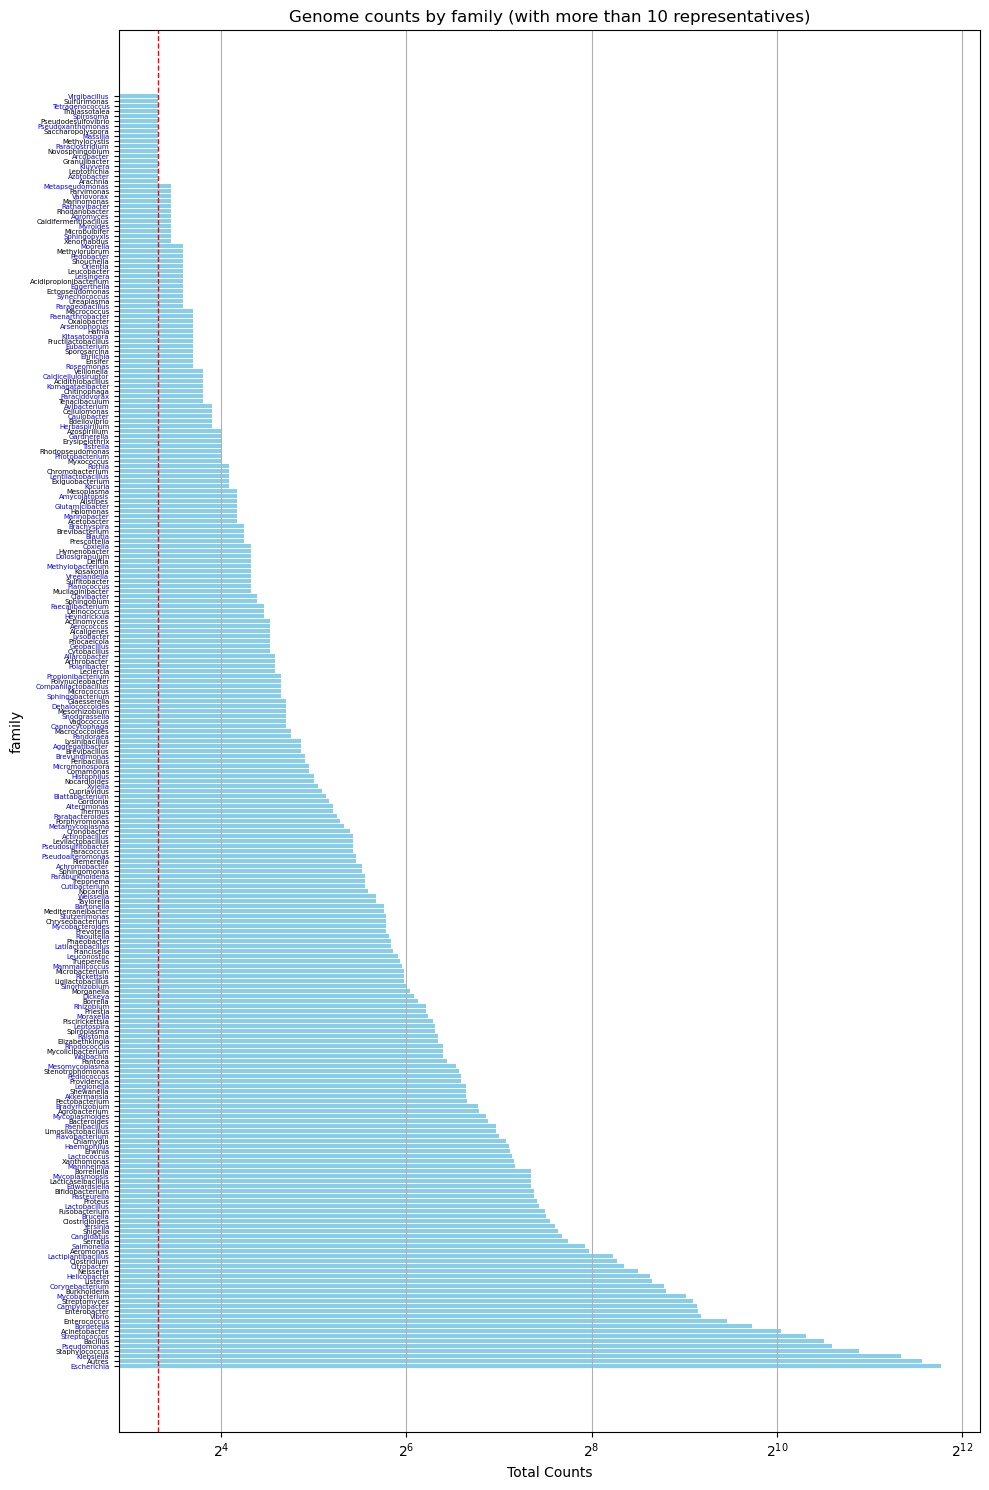

In [46]:
from matplotlib.ticker import LogLocator, MaxNLocator

threshold = 10  # Seuil d'effectif
counts_per_family["Family_Grouped"] = counts_per_family.apply(
    lambda row: row["family"] if row["counts"] >= threshold else "Autres", axis=1
)
# Calculer les effectifs par famille ou groupe "Autres"
grouped_families = counts_per_family.groupby("Family_Grouped")["counts"].sum().reset_index()
# Trier les familles par effectif décroissant
grouped_families_sorted = grouped_families.sort_values(by="counts", ascending=False)
# Création du graphique avec échelle semi-logarithmique
plt.figure(figsize=(10, 15))  # Format portrait
plt.barh(grouped_families_sorted["Family_Grouped"], grouped_families_sorted["counts"], color="skyblue")
plt.xscale('log', base=2)  # Échelle log base 2
#plt.yticks(fontsize=5)  # Rotation des labels et diminution de la taille des légendes
plt.yticks(fontsize=5, color='darkblue')  # Ou même en alternant les couleurs
plt.ylabel('family')
plt.xlabel('Total Counts')
plt.title('Genome counts by family (with more than 10 representatives)')
plt.grid(axis='x')
plt.tight_layout(pad=2)  # Augmente l'espacement autour

plt.gca().xaxis.set_major_locator(LogLocator(base=2.0))
plt.gca().set_yticks(range(len(grouped_families_sorted["Family_Grouped"])))
plt.gca().set_yticklabels(grouped_families_sorted["Family_Grouped"], fontsize=5)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1)
#plt.gca().yaxis.set_major_locator(MaxNLocator(prune='both', nbins=200))  # Par exemple, max 20 labels
for i, label in enumerate(plt.gca().get_yticklabels()):
    color = 'blue' if i % 2 == 0 else 'black'
    label.set_fontsize(5)
    label.set_color(color)
plt.tight_layout()
#plt.subplots_adjust(top=0.95, bottom=0.05)  # Réduit l'espace en haut et en bas
plt.savefig('family_distrib.png', dpi=300)
plt.show()
